# Name: OBAJE PAUL

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Breast Cancer Wisconsin dataset

cancer = load_breast_cancer()

df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

df['target'] = cancer.target

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Check the structure and basic information of the dataset

print("Dataset Information:")
print(df.info())

print("\nDataset Description:")
display(df.describe())

print("\nTarget Classes:")
print(cancer.target_names)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Target Classes:
['malignant' 'benign']


In [4]:
# Check for missing values and duplicate records

print("Missing values:")
print(df.isnull().sum().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values:
0

Number of duplicate rows:
0


In [5]:
# Remove duplicate records and handle missing values

df = df.drop_duplicates()

df = df.dropna()

print("Dataset shape after cleaning:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Dataset shape after cleaning: (569, 31)
Total missing values: 0
Total duplicate rows: 0


Class distribution:
target
1    357
0    212
Name: count, dtype: int64


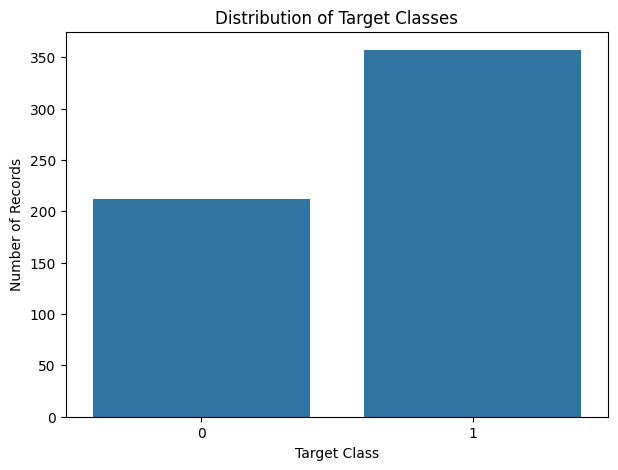

In [6]:
# Check the distribution of the target classes

class_counts = df['target'].value_counts()

print("Class distribution:")
print(class_counts)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='target')
plt.title('Distribution of Target Classes')
plt.xlabel('Target Class')
plt.ylabel('Number of Records')
plt.show()

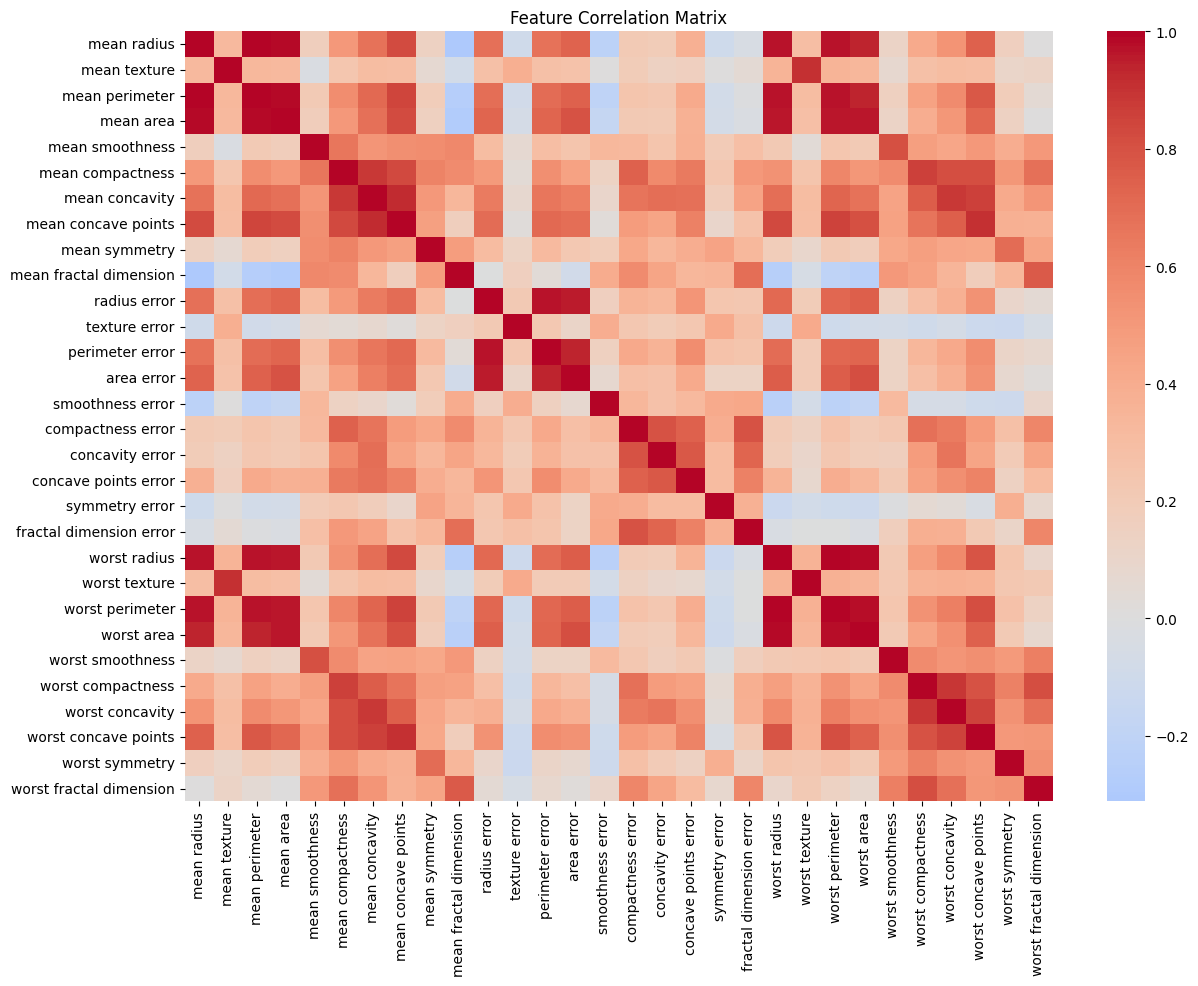

In [7]:
# Examine correlations between selected features

correlation_matrix = df.drop(columns='target').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Matrix')
plt.show()

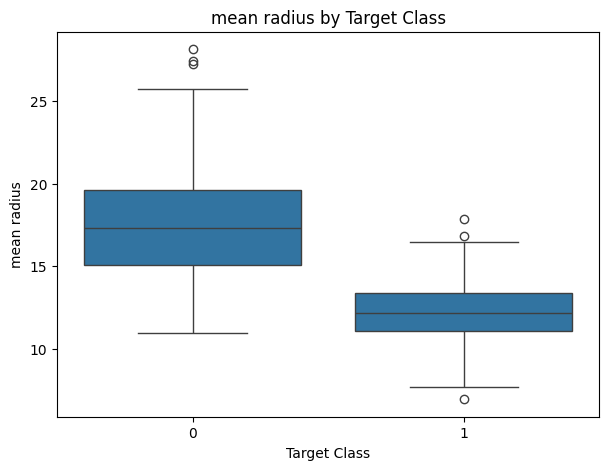

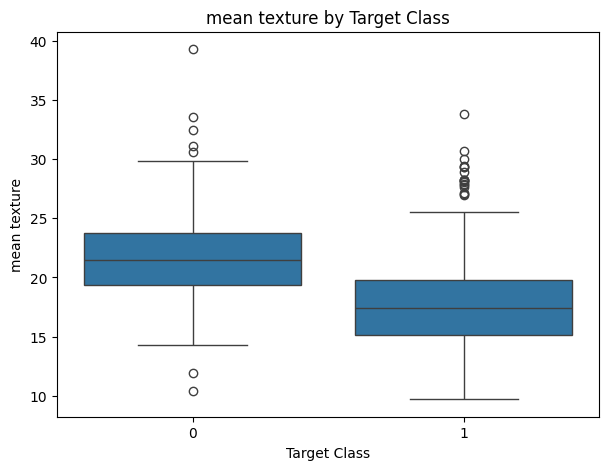

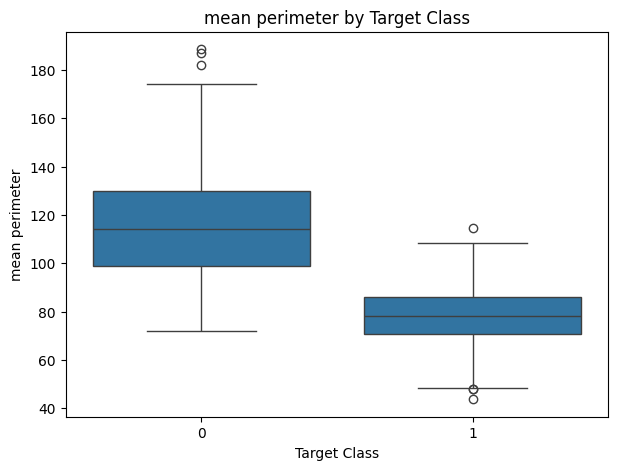

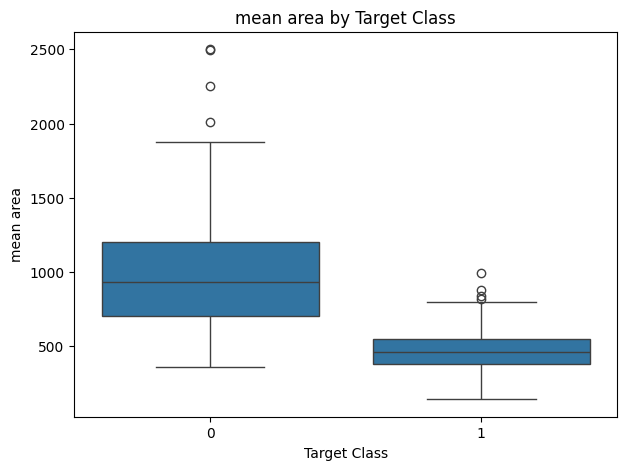

In [8]:
# Examine relationships between selected features and the target

selected_features = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area'
]

for feature in selected_features:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x='target', y=feature)
    plt.title(f'{feature} by Target Class')
    plt.xlabel('Target Class')
    plt.ylabel(feature)
    plt.show()

In [9]:
# Separate the features from the target variable

X = df.drop(columns='target')
y = df['target']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


In [10]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


In [11]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [12]:
# Train the Logistic Regression classification model

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [13]:
# Train the Random Forest classification model

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [14]:
# Generate predictions from both models

logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

random_forest_predictions = random_forest_model.predict(X_test)
random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [15]:
# Calculate classification performance metrics

models = {
    'Logistic Regression': (
        y_test,
        logistic_predictions,
        logistic_probabilities
    ),
    'Random Forest': (
        y_test,
        random_forest_predictions,
        random_forest_probabilities
    )
}

results = []

for model_name, (actual, predictions, probabilities) in models.items():

    accuracy = accuracy_score(actual, predictions)
    precision = precision_score(actual, predictions)
    recall = recall_score(actual, predictions)
    f1 = f1_score(actual, predictions)
    roc_auc = roc_auc_score(actual, probabilities)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993056


In [16]:
# Display detailed classification reports

print("LOGISTIC REGRESSION")
print(classification_report(y_test, logistic_predictions))

print("\nRANDOM FOREST")
print(classification_report(y_test, random_forest_predictions))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



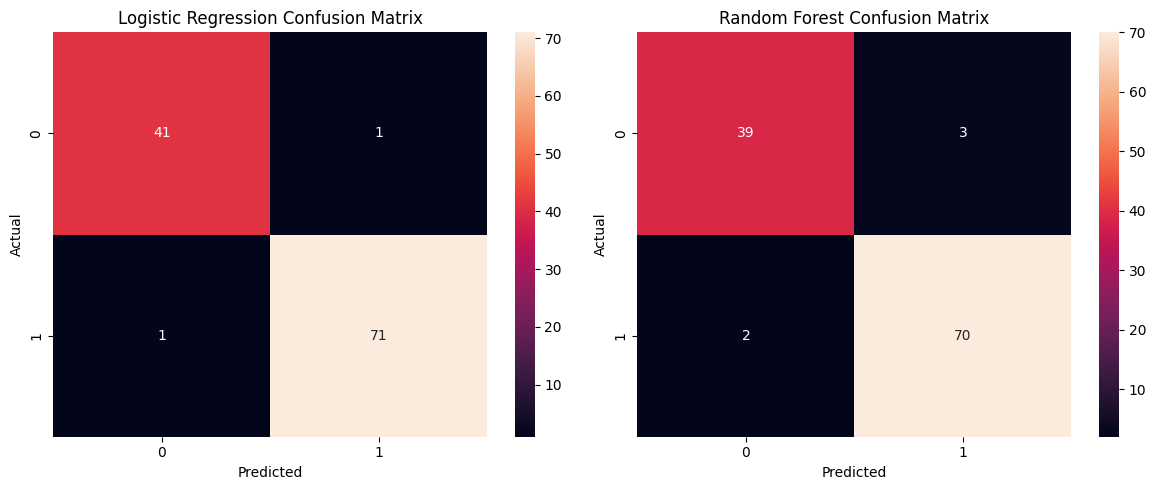

In [17]:
# Display confusion matrices for both models

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logistic = confusion_matrix(y_test, logistic_predictions)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    ax=axes[0]
)

axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


cm_random_forest = confusion_matrix(
    y_test,
    random_forest_predictions
)

sns.heatmap(
    cm_random_forest,
    annot=True,
    fmt='d',
    ax=axes[1]
)

axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

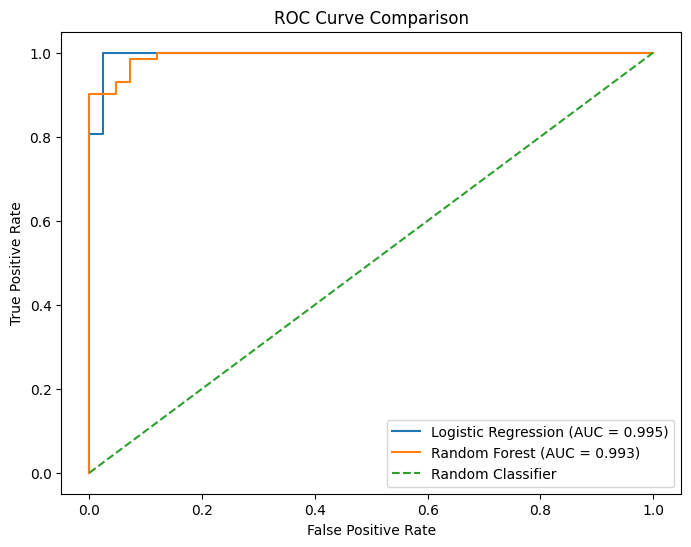

In [18]:
# Compare ROC curves for both classification models

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    random_forest_probabilities
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

rf_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f'Logistic Regression (AUC = {logistic_auc:.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [19]:
# Identify the model with the highest F1 score

best_model = results_df.loc[
    results_df['F1 Score'].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
ROC-AUC                  0.99537
Name: 0, dtype: object


,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


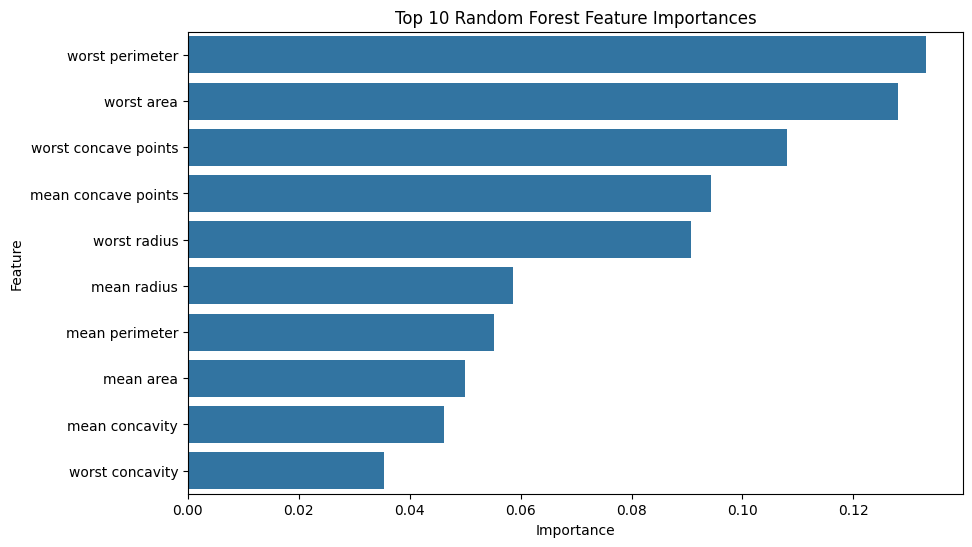

In [20]:
# Examine the most important features for the Random Forest model

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance.head(10))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [21]:
# Demonstrate how the trained model can classify a new observation

sample_input = X_test.iloc[[0]]

sample_prediction = random_forest_model.predict(sample_input)

if sample_prediction[0] == 0:
    prediction_label = 'Malignant'
else:
    prediction_label = 'Benign'

print("Predicted class:", prediction_label)

Predicted class: Malignant


## Deployment and Monitoring

The selected classification model can be deployed as a small web API using Flask or FastAPI. The trained model and preprocessing steps can be saved and loaded by the application so that new observations can be classified when they are received.

In a production environment, incoming data may contain missing values, unexpected formats, or feature values that are different from the training data. These issues should be checked before making predictions.

The model should also be monitored after deployment. Important monitoring areas include prediction accuracy, changes in the distribution of incoming data, missing values, and changes in model performance. If performance drops significantly, the model should be reviewed and retrained using newer data.

Regular monitoring is important because the relationship between the input features and the target class may change over time.

## Conclusion

This project applied supervised machine learning classification to the Breast Cancer Wisconsin dataset. The data was cleaned, explored and divided into training and testing sets before training two classification models: Logistic Regression and Random Forest.

Both models were evaluated using accuracy, precision, recall, F1-score and ROC-AUC. Confusion matrices and ROC curves were also used to examine their classification performance.

The model comparison shows which classifier provides the strongest overall performance on the test data. The Random Forest feature importance analysis also provides an indication of which features contribute most to its predictions.

Overall, the project demonstrates the complete classification workflow from preprocessing and exploratory analysis to model training, evaluation, interpretation and deployment considerations.